# Importing Libraries

In [70]:
from PIL import Image
from PIL.ExifTags import TAGS, GPSTAGS
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt
import os
import piexif
import math
from math import sin, cos, sqrt, atan2, radians

# Loading All Images from a folder

In [71]:
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        images.append(filename)
    return images

# Entering File Location

In [4]:
filename=load_images_from_folder("C:\\Users\\Rohit\\Documents\Flood-Alert-Application\Simulation\\mumbai flood/")

In [5]:
filename=load_images_from_folder("C:\\Users\\Rohit\\Documents\Flood-Alert-Application\Simulation\\chennai flood")

In [72]:
filename=load_images_from_folder("C:\\Users\\Rohit\\Documents\Flood-Alert-Application\Simulation\\kolkata flood")

# Converting decimal degrees to degree, minute, second

In [6]:
def decdeg2dms(dd):
    mnt,sec = divmod(dd*3600,60)
    deg,mnt = divmod(mnt,60)
    return deg,mnt,sec

In [7]:
#List of cluster centers in chennai
centerlat=[13.1187,13.0764,13.0086,12.8389,12.932294,13.001666]
centerlon=[80.2622,80.2073,80.2186,80.2165,80.182318, 80.137055]

In [8]:
#List of cluster centers in mumbai
centerlat=[19.2313,18.9652,19.2380,19.0058,19.1849,19.1159,19.0600,19.1166,19.1628,19.2168,19.1369]
centerlon=[72.7945,72.8219,72.8531,72.8439,72.8494,72.8510,72.8966,72.9103,72.9502,72.9790,72.8314]

# (First Method) Function to calculate distance between two coordinates

In [9]:
def distance(originlat,originlon,destlat,destlon):
    from math import sin, cos, sqrt, atan2, radians
    lat=[0,0]
    lon=[0,0]
    R=6373.0
    lat[0]=radians(originlat)
    lon[0]=radians(originlon)
    lat[1]=radians(destlat)
    lon[1]=radians(destlon)
    dlon=lon[1]-lon[0]
    dlat=lat[1]-lat[0]
    a= sin(dlat/ 2)**2 + cos(lat[0]) * cos(lat[1]) * sin(dlon/ 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
  #  print(originlat,",",originlon,",",destlat,",",destlon)
    distance = R * c
    return distance

# Method 1: Generating random coordinates within a rectangular boundary and selecting the point if it is within 2 Km radius 

In [132]:
destlat=0
destlon=0
index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_1"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
        
        
    if(val>0):       
        cluster_size=random.randrange(20,50,1) #Having a cluster size within 30 to 80
    
    val = val-cluster_size 
    
    cluster.append(cluster_size)
        
    for j in range(cluster_size): 
        try:
            img = Image.open(source + "/"+filename[index])
            img=img.convert('RGB')
            while(1):
                destlat=random.randrange(188927,193032,33) #manually enter the latitude*10000 range and the steps
                destlon=random.randrange(727799,730118,18) #manually enter the longitude*10000 range and the steps
                x=distance(centerlat[i],centerlon[i],destlat/10000,destlon/10000)
                
                if(x<2): #If distance is <2 Km, we break out of the infinite loop
                    break                
            
            #Converting decimal degree to degree, minute, second
            deglat,mntlat,seclat=decdeg2dms(destlat/10000)
            deglon,mntlon,seclon=decdeg2dms(destlon/10000)
            
            #Preparing the structure of coordinate data
            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            #Save image in desxtination folder
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [133]:
cluster #No. of points in each cluster

[36, 36, 30, 43, 44, 26, 26, 47, 49, 39, 39]

# Method 2: Generating random coordinates from a normal multivariate distribution within a rectangular boundary and selecting a point within it

In [151]:
destlat=0
destlon=0

index=0

val=494 # Total images in the folder

cluster_size=0
cluster=[]

source = "mumbai flood"
dest = "test_mumbai_2"

for i in range(len(centerlat)):
    
    if(i==len(centerlat)-1):
        cluster_size=val
    
    if(val>0):       
        cluster_size=random.randrange(20,50,1)
        
    val = val-cluster_size
            
    cluster.append(cluster_size)
    
    x, y = np.random.multivariate_normal([centerlat[i], centerlon[i]], [[1, 0],[0, 1]],cluster_size).T
    
    x=(x-min(x))/(max(x)-min(x)) #Normalization
    y=(y-min(y))/(max(y)-min(y)) #Normalization
    
    x=centerlat[i]-0.02+0.04*x #Going 2km down and multiplying 4km with a value picked from a normal distribution
    y=centerlon[i]-0.02+0.04*y #Going 2km left and multiplying 4km with a value picked from a normal distribution
    
    for j in range(cluster_size):
        try:
            
            img = Image.open(source + "/" + filename[index])
            
            img=img.convert('RGB')
            
            deglat,mntlat,seclat=decdeg2dms(x[j])
            deglon,mntlon,seclon=decdeg2dms(y[j])
            

            gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
                   piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
                   piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
                   piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
                   }
            exif_dict = {"GPS":gps_ifd}
            exif_bytes = piexif.dump(exif_dict)
            
            #print(filename[index])
            
            img.save(dest + "/" + filename[index], exif=exif_bytes)
            index=index+1
            
        except:
            index=index+1
            continue

In [152]:
cluster #No. of points in each cluster

[41, 26, 30, 23, 20, 47, 43, 37, 28, 32, 35]

# Extracting Geolocation Data From Images

In [122]:
class ImageMetaData(object):
    exif_data = None
    image = None

    def __init__(self, img_path):
        self.image = Image.open(img_path)
        #print(self.image._getexif())
        self.get_exif_data()
        super(ImageMetaData, self).__init__()

    def get_exif_data(self):
        """Returns a dictionary from the exif data of an PIL Image item. Also converts the GPS Tags"""
        exif_data = {}
        info = self.image._getexif()
        if info:
            for tag, value in info.items():
                decoded = TAGS.get(tag, tag)
                if decoded == "GPSInfo":
                    gps_data = {}
                    for t in value:
                        sub_decoded = GPSTAGS.get(t, t)
                        gps_data[sub_decoded] = value[t]

                    exif_data[decoded] = gps_data
                else:
                    exif_data[decoded] = value
                    
        self.exif_data = exif_data
        return exif_data

    def get_if_exist(self, data, key):
        if key in data:
            return data[key]
        return None

    def convert_to_degress(self, value):

        """Helper function to convert the GPS coordinates 
        stored in the EXIF to degress in float format"""
        d0 = value[0]
        d = float(d0)

        m0 = value[1]
        m = float(m0)

        s0 = value[2]
        s = float(s0)

        return d + (m / 60.0) + (s / 3600.0)

    def get_lat_lng(self):
        """Returns the latitude and longitude, if available, from the provided exif_data (obtained through get_exif_data above)"""
        lat = None
        lng = None
        exif_data = self.get_exif_data()
        if "GPSInfo" in exif_data:      
            gps_info = exif_data["GPSInfo"]
            gps_latitude = self.get_if_exist(gps_info, "GPSLatitude")
            gps_latitude_ref = self.get_if_exist(gps_info, 'GPSLatitudeRef')
            gps_longitude = self.get_if_exist(gps_info, 'GPSLongitude')
            gps_longitude_ref = self.get_if_exist(gps_info, 'GPSLongitudeRef')
            if gps_latitude and gps_longitude:
                lat = self.convert_to_degress(gps_latitude)
                lng = self.convert_to_degress(gps_longitude)
        return lat, lng

# Reading file having images with simulated locations

In [147]:
source = "test_mumbai_1"
filename=load_images_from_folder(source + "/")

# Getting latitude and longitude of images

In [148]:
lat =[]
lng = []
for i in range(len(filename)):
    path_name = source + "/" + filename[i]
    meta_data =  ImageMetaData(path_name)
    x, y= meta_data.get_lat_lng()
    lat.append(x)
    lng.append(y)

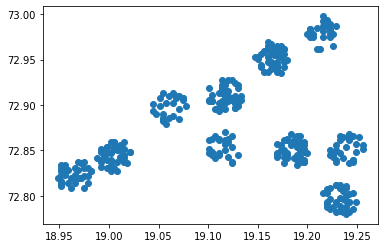

In [149]:
plt.scatter(lat,lng)

# (Second Method) Suggested by Ashish Sir

In [116]:
#Chennai
# Tambaram, Thoraipakkam, T.Nagar, Thiruvallur, Perambur, Ambattur, Porur, Egmore, Thirumazhisai, Sriperumbudur
centres=[[12.917245951763109, 80.09423789532667],[12.948397384259001, 80.21163709642875],[13.04221456750658, 80.22934259842798],[13.115616117533381, 79.90653410341457],[13.122237329446282, 80.23125956412602],[13.11666631997288, 80.14717267250168],[13.034611333987725, 80.15129102598517],[13.062223507062361, 80.04733522144163],[13.00931701821481, 80.18797833350868],[12.963764924495308, 79.94132618593319]]
sd2=[0.0090,0.0090,0.0095,0.0095,0.0095,0.0095,0.0050,0.0095,0.0090,0.0098]

#Chennai
#rectangle_leftcorner=[[13.018443,80.144705],[13.026470, 80.280661],[13.072124,80.290445],[13.11108, 80.295252]]
#rectangle_rightcorner=[[13.069950, 80.108313],[13.069950,80.152601],[13.111416,80.150026],[13.132480, 80.192255]]
rectangle_leftcorner=[[12.92373408813119, 79.88049479641093],[12.869840664046325, 80.22604569947062],[13.032903480850525, 80.2696942355997],[13.181693203063451, 80.29733830368916]]
rectangle_rightcorner=[[13.034320950806237, 79.84339353772012],[13.14202474717776, 79.87831236662336],[13.175318347635548, 80.08055058402137],[22.819396579333564, 88.21223072696722]]


val=494 # Total images in the folder

source = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\chennai flood"
dest = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\chennai flood_new_method"

In [130]:
#Mumbai
# Dadar, Chembur, Andheri, Malad, Borivali, Thane, Navi Mumbai, Dombivli, Airoli, Bhiwandi
centres=[[19.018619455632507, 72.84583975582304],[19.056104997428307, 72.89867796082896],[19.11515500727002, 72.86159910201802],[19.18650598870332, 72.84546293172963],[19.235784983743407, 72.85610593791993],[19.204663125982744, 72.97832884171184],[19.037931530246006, 73.03154386602067],[19.22250408001917, 73.09666938248976],[19.157979306713013, 72.99607581304869],[19.286031363159147, 73.0496341635841]]
sd2=[0.0040,0.0030,0.0035,0.0045,0.0045,0.0035,0.0050,0.0035,0.0060,0.0055]

#Mumbai
rectangle_leftcorner=[[18.9751198210964, 72.81425406399514],[19.07833175002693, 72.82867362706747],[19.14191465609462, 72.81631400728575],[19.305949011151974, 72.86712577646665]]
rectangle_rightcorner=[[18.966678277307473, 72.83965994974312],[19.040689545921005, 72.91862418595524],[19.004337248616135, 73.14453056974347],[19.371387246975214, 73.10951164197097]]

val=494 # Total images in the folder

source = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\mumbai flood"
dest = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\mumbai flood_new_method"

In [159]:
#Kolkata
# Baranagar, Bidhannagar, Behala, Bowbazar, Behala, Kasba, Sonarpur, Howrah, Barasat, Barrackpore
centres=[[22.645111302744468, 88.38415201146343],[22.583842253527962, 88.41285350849434],[22.503903153143593, 88.31912518225275],[22.571085741750093, 88.36200472569422],[22.50431746463976, 88.3213674867083],[22.521337047745256, 88.38257682624538],[22.45463842181825, 88.3958008549933],[22.599722661776372, 88.26027023792567],[22.72216246930668, 88.47406687338444],[22.765072222476864, 88.38100505957213]]
sd2=[0.0050,0.0080,0.0085,0.0070,0.0065,0.0075,0.0080,0.0055,0.0040,0.0075]

#Kolkata
rectangle_leftcorner=[[22.47559556825974, 88.23058679749178],[22.575048098658737, 88.21167243183585],[22.667716255716776, 88.26696057759933],[22.81800512207815, 88.30301451911212]]
rectangle_rightcorner=[[22.442398969683435, 88.44592217835904],[22.536597848098875, 88.55310292279424],[22.71435367114243, 88.54264626480057],[22.80515340492663, 88.45550744818658]]

val=494 # Total images in the folder

source = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\kolkata flood"
dest = "C:\\Users\Rohit\Documents\Flood-Alert-Application\Simulation\kolkata flood_new_method"

In [160]:
data=[]
remaining_images=394
for i in range(10):
    src=centres[i]
    r=sd2[i]

    np.random.seed(i)
    
    if(remaining_images<40 or i==9):
        no = remaining_images
    else:
        no = random.randrange(25,50,1)
        remaining_images = remaining_images - no
    #no=13+6*i #13 constant, 6 variable
    
    value1 = np.random.normal(src[0],r,no)
    value2 = np.random.normal(src[1],r,no)
    
    for j in range(no):
        x_cord=value1[j]
        y_cord=value2[j]
        
        data.append([x_cord,y_cord])

In [161]:
np.random.seed(17)

no=[20,30,20,30] #Total random points = 100

for i in range(len(no)):
    lng_rand=np.random.rand(no[i])
    lat_rand=np.random.rand(no[i])
    k=0

    lng_min=min(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])
    lng_max=max(rectangle_leftcorner[i][1],rectangle_rightcorner[i][1])
    lat_min=min(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])
    lat_max=max(rectangle_leftcorner[i][0],rectangle_rightcorner[i][0])

    for j in range(no[i]):
        x_cord=lat_min+lat_rand[j]*(lat_max-lat_min)
        y_cord=lng_min+lng_rand[j]*(lng_max-lng_min)
        data.append([x_cord,y_cord])

In [162]:
df=pd.DataFrame(data,columns=['lat','lng'])

In [163]:
df.to_excel("output.xlsx")

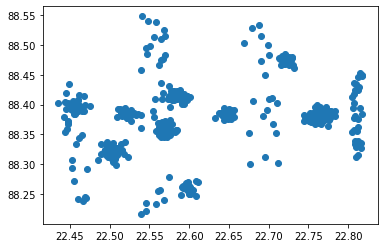

In [164]:
plt.scatter(df.loc[:,"lat"],df.loc[:,"lng"])

In [165]:
destlat=0
destlon=0
index=0
cluster_size=0
cluster=[]

In [166]:
index=0
for i in range(len(df)):
    try:
        img = Image.open(source + "/" + filename[index])

        img=img.convert('RGB')

        deglat,mntlat,seclat=decdeg2dms(df["lat"][i])
        deglon,mntlon,seclon=decdeg2dms(df["lng"][i])
    

        gps_ifd = {piexif.GPSIFD.GPSVersionID: (2, 0, 0, 0),
               piexif.GPSIFD.GPSLatitude: ((int(deglat), 1), (int(mntlat), 1), (int(seclat*10000),10000)),
               piexif.GPSIFD.GPSLongitude:((int(deglon), 1), (int(mntlon), 1), (int(seclon*10000),10000)),
               piexif.GPSIFD.GPSDateStamp: u"1999:99:99 99:99:99",
               }
        exif_dict = {"GPS":gps_ifd}
        exif_bytes = piexif.dump(exif_dict)

        print(filename[index])

        img.save(dest + "/" + filename[index], exif=exif_bytes)
        index=index+1

    except Exception as e:
        print(e)
        index=index+1
        continue

kolkata_flood_0.jpg
kolkata_flood_1.jpg
kolkata_flood_10.jpg
kolkata_flood_100.jpg
kolkata_flood_101.jpg
kolkata_flood_102.jpg
kolkata_flood_103.jpg
kolkata_flood_104.jpg
kolkata_flood_105.jpg
kolkata_flood_106.jpg
kolkata_flood_107.jpg
kolkata_flood_108.jpg
kolkata_flood_109.jpg
kolkata_flood_11.jpg
kolkata_flood_110.jpg
kolkata_flood_111.jpg
kolkata_flood_112.jpg
kolkata_flood_113.jpg
kolkata_flood_114.jpg
kolkata_flood_115.jpg
kolkata_flood_116.jpg
kolkata_flood_117.jpg
kolkata_flood_118.jpg
kolkata_flood_119.jpg
kolkata_flood_12.jpg
kolkata_flood_120.jpg
kolkata_flood_121.jpg
kolkata_flood_122.jpg
kolkata_flood_123.jpg
kolkata_flood_124.jpg
kolkata_flood_125.jpg
kolkata_flood_126.jpg
kolkata_flood_127.jpg
kolkata_flood_128.jpg
kolkata_flood_129.jpg
kolkata_flood_13.jpg
kolkata_flood_130.jpg
kolkata_flood_131.jpg
kolkata_flood_132.jpg
kolkata_flood_133.jpg
kolkata_flood_134.jpg
kolkata_flood_135.jpg
kolkata_flood_136.jpg
kolkata_flood_137.jpg
kolkata_flood_138.jpg
kolkata_flood_139.

kolkata_flood_442.jpg
kolkata_flood_443.jpg
kolkata_flood_444.jpg
kolkata_flood_445.jpg
kolkata_flood_446.jpg
kolkata_flood_447.jpg
kolkata_flood_448.jpg
kolkata_flood_449.jpg
kolkata_flood_45.jpg
kolkata_flood_450.jpg
kolkata_flood_451.jpg
kolkata_flood_452.jpg
kolkata_flood_453.jpg
kolkata_flood_454.jpg
kolkata_flood_455.jpg
kolkata_flood_456.jpg
kolkata_flood_457.jpg
kolkata_flood_458.jpg
kolkata_flood_459.jpg
kolkata_flood_46.jpg
kolkata_flood_460.jpg
kolkata_flood_461.jpg
kolkata_flood_462.jpg
kolkata_flood_463.jpg
kolkata_flood_464.jpg
kolkata_flood_465.jpg
kolkata_flood_466.jpg
kolkata_flood_467.jpg
kolkata_flood_468.jpg
kolkata_flood_469.jpg
kolkata_flood_47.jpg
kolkata_flood_470.jpg
kolkata_flood_471.jpg
kolkata_flood_472.jpg
kolkata_flood_473.jpg
kolkata_flood_474.jpg
kolkata_flood_475.jpg
kolkata_flood_476.jpg
kolkata_flood_477.jpg
kolkata_flood_478.jpg
kolkata_flood_479.jpg
kolkata_flood_48.jpg
kolkata_flood_480.jpg
kolkata_flood_481.jpg
kolkata_flood_482.jpg
kolkata_flood_